# Домашнее задание 06: Деревья решений и ансамбли

## Загрузка данных и первичный анализ

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, precision_recall_curve, average_precision_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.calibration import CalibratedClassifierCV

import joblib
import json
import os

%matplotlib inline
plt.style.use('seaborn-v0_8')

In [2]:
# Загрузка данных
df = pd.read_csv('S06-hw-dataset-01.csv')
print(f"Размерность датасета: {df.shape}")
print("\nПервые 5 строк:")
print(df.head())
print("\nИнформация о датасете:")
print(df.info())
print("\nБазовые статистики:")
print(df.describe())
print("\nРаспределение таргета:")
print(df['target'].value_counts(normalize=True))

Размерность датасета: (12000, 30)

Первые 5 строк:
   id     num01     num02     num03     num04     num05     num06     num07  \
0   1 -0.946058 -0.070313  1.824445 -2.754422  0.808865 -0.111094 -0.268950   
1   2 -2.484027  0.739378  1.596908 -2.586479 -0.033225 -3.054412 -4.706908   
2   3  1.522629  7.159635 -0.564903 -4.493110  1.623610  5.450187 -0.974595   
3   4  0.463373 -1.073908  1.752813  0.362786  2.790872  4.082385  0.322283   
4   5  3.188390 -4.701692 -0.689918 -0.448995  0.373821 -3.275363 -1.760931   

      num08     num09  ...     num20     num21     num22     num23     num24  \
0 -3.078210  0.801275  ... -1.616515 -1.989464  1.407390 -0.218362  2.016052   
1 -9.795169  0.145911  ... -1.727040 -0.583997  1.136761  0.285978 -0.310879   
2 -5.189589  1.600591  ...  0.524408  2.022430  1.278358 -0.850547  0.847457   
3  3.390984 -0.033929  ...  2.399834 -1.431576 -0.746987  0.049639  2.414689   
4  0.923689  0.537345  ... -2.183407 -2.896590  2.440343 -1.097168  1.4573

In [3]:
# Проверка пропусков и типов столбцов
print("Пропуски:")
print(df.isnull().sum())
print("\nТипы столбцов:")
print(df.dtypes)

# Определение X и y
X = df.drop(['target', 'id'], axis=1)
y = df['target']

print(f"\nРазмерность X: {X.shape}")
print(f"Размерность y: {y.shape}")
print(f"Количество уникальных значений в y: {y.nunique()}")
print(f"Значения в y: {sorted(y.unique())}")

Пропуски:
id               0
num01            0
num02            0
num03            0
num04            0
num05            0
num06            0
num07            0
num08            0
num09            0
num10            0
num11            0
num12            0
num13            0
num14            0
num15            0
num16            0
num17            0
num18            0
num19            0
num20            0
num21            0
num22            0
num23            0
num24            0
cat_contract     0
cat_region       0
cat_payment      0
tenure_months    0
target           0
dtype: int64

Типы столбцов:
id                 int64
num01            float64
num02            float64
num03            float64
num04            float64
num05            float64
num06            float64
num07            float64
num08            float64
num09            float64
num10            float64
num11            float64
num12            float64
num13            float64
num14            float64
num15           

## Train/Test-сплит и воспроизводимость

In [4]:
# Разделение данных на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Размерность X_train: {X_train.shape}")
print(f"Размерность X_test: {X_test.shape}")
print(f"Доля классов в y_train: {y_train.value_counts(normalize=True)}")
print(f"Доля классов в y_test: {y_test.value_counts(normalize=True)}")

# Объяснение важности фиксированного seed и стратификации
print("\nФиксированный random_state обеспечивает воспроизводимость результатов.")
print("Stratify=y гарантирует, что пропорции классов сохраняются в train и test выборках.")

Размерность X_train: (9600, 28)
Размерность X_test: (2400, 28)
Доля классов в y_train: target
0    0.676562
1    0.323437
Name: proportion, dtype: float64
Доля классов в y_test: target
0    0.676667
1    0.323333
Name: proportion, dtype: float64

Фиксированный random_state обеспечивает воспроизводимость результатов.
Stratify=y гарантирует, что пропорции классов сохраняются в train и test выборках.


## Baseline'ы

In [5]:
# DummyClassifier
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_clf.fit(X_train, y_train)
dummy_pred = dummy_clf.predict(X_test)

dummy_accuracy = accuracy_score(y_test, dummy_pred)
dummy_f1 = f1_score(y_test, dummy_pred)

print(f"DummyClassifier - Accuracy: {dummy_accuracy:.4f}")
print(f"DummyClassifier - F1: {dummy_f1:.4f}")

DummyClassifier - Accuracy: 0.6767
DummyClassifier - F1: 0.0000


In [6]:
# LogisticRegression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=42, max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)
lr_proba = lr_pipeline.predict_proba(X_test)[:, 1]

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
lr_roc_auc = roc_auc_score(y_test, lr_proba)

print(f"LogisticRegression - Accuracy: {lr_accuracy:.4f}")
print(f"LogisticRegression - F1: {lr_f1:.4f}")
print(f"LogisticRegression - ROC-AUC: {lr_roc_auc:.4f}")

LogisticRegression - Accuracy: 0.8275
LogisticRegression - F1: 0.7076
LogisticRegression - ROC-AUC: 0.8747


## Модели недели 6

### Decision Tree Classifier

In [7]:
# Decision Tree с контролем сложности
dt_params = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [5, 10, 20, 30]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)
dt_best = dt_grid.best_estimator_

print(f"Лучшие параметры для дерева: {dt_grid.best_params_}")
print(f"Лучший CV ROC-AUC: {dt_grid.best_score_:.4f}")

# Предсказания
dt_pred = dt_best.predict(X_test)
dt_proba = dt_best.predict_proba(X_test)[:, 1]

# Метрики
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_roc_auc = roc_auc_score(y_test, dt_proba)

print(f"Decision Tree - Accuracy: {dt_accuracy:.4f}")
print(f"Decision Tree - F1: {dt_f1:.4f}")
print(f"Decision Tree - ROC-AUC: {dt_roc_auc:.4f}")

Лучшие параметры для дерева: {'max_depth': 10, 'min_samples_leaf': 20}
Лучший CV ROC-AUC: 0.9138
Decision Tree - Accuracy: 0.8683
Decision Tree - F1: 0.7879
Decision Tree - ROC-AUC: 0.9067


### Random Forest Classifier

In [8]:
# Random Forest
rf_params = {
    'n_estimators': [100],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [5, 10, 20],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_

print(f"Лучшие параметры для Random Forest: {rf_grid.best_params_}")
print(f"Лучший CV ROC-AUC: {rf_grid.best_score_:.4f}")

# Предсказания
rf_pred = rf_best.predict(X_test)
rf_proba = rf_best.predict_proba(X_test)[:, 1]

# Метрики
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_proba)

print(f"Random Forest - Accuracy: {rf_accuracy:.4f}")
print(f"Random Forest - F1: {rf_f1:.4f}")
print(f"Random Forest - ROC-AUC: {rf_roc_auc:.4f}")

Лучшие параметры для Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 100}
Лучший CV ROC-AUC: 0.9662
Random Forest - Accuracy: 0.9225
Random Forest - F1: 0.8726
Random Forest - ROC-AUC: 0.9648


### Gradient Boosting Classifier

In [9]:
# Gradient Boosting
gb_params = {
    'n_estimators': [100],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)
gb_best = gb_grid.best_estimator_

print(f"Лучшие параметры для Gradient Boosting: {gb_grid.best_params_}")
print(f"Лучший CV ROC-AUC: {gb_grid.best_score_:.4f}")

# Предсказания
gb_pred = gb_best.predict(X_test)
gb_proba = gb_best.predict_proba(X_test)[:, 1]

# Метрики
gb_accuracy = accuracy_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)
gb_roc_auc = roc_auc_score(y_test, gb_proba)

print(f"Gradient Boosting - Accuracy: {gb_accuracy:.4f}")
print(f"Gradient Boosting - F1: {gb_f1:.4f}")
print(f"Gradient Boosting - ROC-AUC: {gb_roc_auc:.4f}")

Лучшие параметры для Gradient Boosting: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100}
Лучший CV ROC-AUC: 0.9711
Gradient Boosting - Accuracy: 0.9304
Gradient Boosting - F1: 0.8901
Gradient Boosting - ROC-AUC: 0.9690


### Stacking Classifier

In [10]:
# Stacking
estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('lr', Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(random_state=42, max_iter=1000))
    ]))
]

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

stacking_clf.fit(X_train, y_train)

# Предсказания
stack_pred = stacking_clf.predict(X_test)
stack_proba = stacking_clf.predict_proba(X_test)[:, 1]

# Метрики
stack_accuracy = accuracy_score(y_test, stack_pred)
stack_f1 = f1_score(y_test, stack_pred)
stack_roc_auc = roc_auc_score(y_test, stack_proba)

print(f"Stacking - Accuracy: {stack_accuracy:.4f}")
print(f"Stacking - F1: {stack_f1:.4f}")
print(f"Stacking - ROC-AUC: {stack_roc_auc:.4f}")

Stacking - Accuracy: 0.9313
Stacking - F1: 0.8911
Stacking - ROC-AUC: 0.9672


## Сравнение моделей

In [11]:
# Сравнение всех моделей
results = pd.DataFrame({
    'Model': ['Dummy', 'Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'Stacking'],
    'Accuracy': [dummy_accuracy, lr_accuracy, dt_accuracy, rf_accuracy, gb_accuracy, stack_accuracy],
    'F1': [dummy_f1, lr_f1, dt_f1, rf_f1, gb_f1, stack_f1],
    'ROC_AUC': [np.nan, lr_roc_auc, dt_roc_auc, rf_roc_auc, gb_roc_auc, stack_roc_auc]
})

print(results)

# Определение лучшей модели по ROC-AUC
best_model_idx = results['ROC_AUC'].dropna().idxmax()
best_model_name = results.loc[best_model_idx, 'Model']
print(f"\nЛучшая модель по ROC-AUC: {best_model_name}")

                 Model  Accuracy        F1   ROC_AUC
0                Dummy  0.676667  0.000000       NaN
1  Logistic Regression  0.827500  0.707627  0.874691
2        Decision Tree  0.868333  0.787919  0.906695
3        Random Forest  0.922500  0.872603  0.964845
4    Gradient Boosting  0.930417  0.890059  0.968986
5             Stacking  0.931250  0.891089  0.967173

Лучшая модель по ROC-AUC: Gradient Boosting


## Диагностические графики

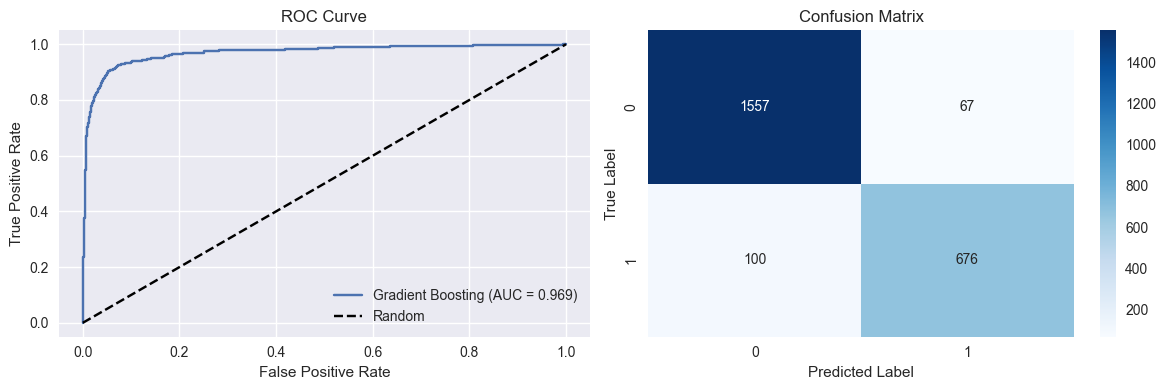

In [12]:
# Выбор лучшей модели для построения графиков
if best_model_name == 'Logistic Regression':
    best_model = lr_pipeline
    best_proba = lr_proba
elif best_model_name == 'Decision Tree':
    best_model = dt_best
    best_proba = dt_proba
elif best_model_name == 'Random Forest':
    best_model = rf_best
    best_proba = rf_proba
elif best_model_name == 'Gradient Boosting':
    best_model = gb_best
    best_proba = gb_proba
else:  # Stacking
    best_model = stacking_clf
    best_proba = stack_proba

# ROC-кривая
fpr, tpr, _ = roc_curve(y_test, best_proba)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {roc_auc_score(y_test, best_proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)

# Confusion Matrix
best_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, best_pred)
plt.subplot(1, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('artifacts/figures/roc_cm.png', dpi=150, bbox_inches='tight')
plt.show()

## Интерпретация

Top 15 признаков по permutation importance:
   feature  importance_mean  importance_std
18   num19         0.111042        0.005070
17   num18         0.101333        0.006174
6    num07         0.059708        0.002059
3    num04         0.026083        0.002321
23   num24         0.021958        0.002733
19   num20         0.017875        0.002544
15   num16         0.014458        0.002042
0    num01         0.012583        0.001935
20   num21         0.011333        0.002831
13   num14         0.010542        0.002789
21   num22         0.010333        0.001970
16   num17         0.009583        0.002050
7    num08         0.007792        0.002379
12   num13         0.005500        0.002442
1    num02         0.005333        0.002147


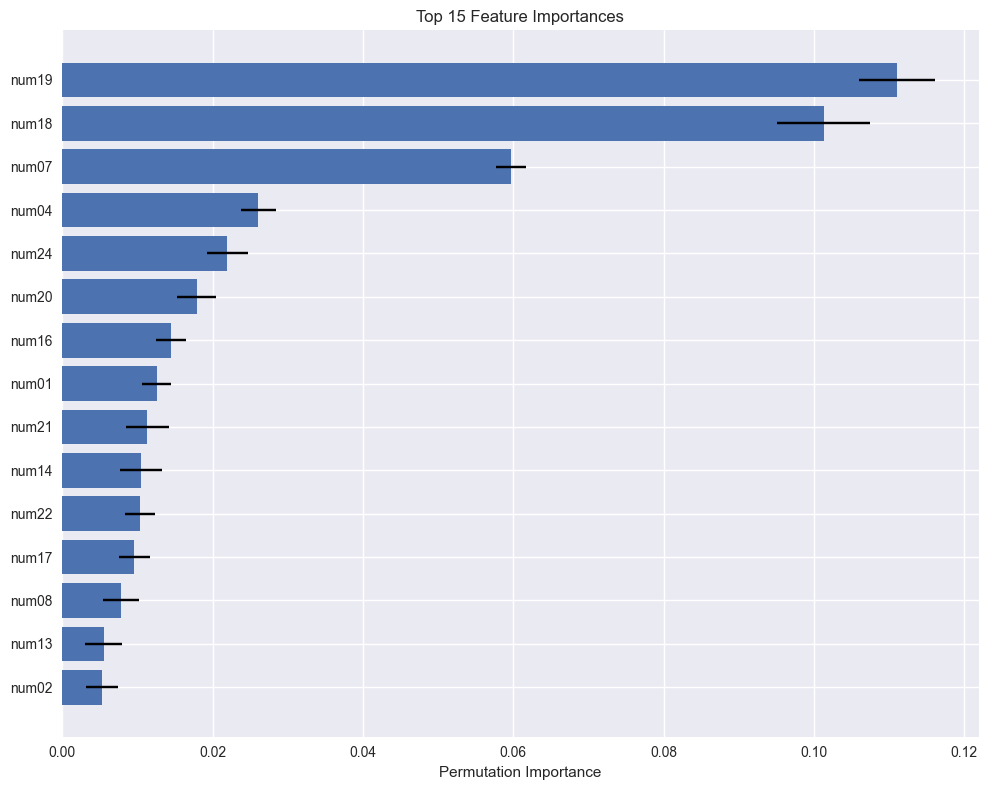

In [13]:
# Permutation importance для лучшей модели
perm_importance = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42)

# Получаем топ-10 признаков
feature_names = X.columns
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

top_features = importance_df.head(15)
print("Top 15 признаков по permutation importance:")
print(top_features)

# Визуализация
plt.figure(figsize=(10, 8))
plt.barh(range(len(top_features)), top_features['importance_mean'], xerr=top_features['importance_std'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Permutation Importance')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('artifacts/figures/importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Сохранение артефактов

In [14]:
# Создание папки artifacts если не существует
os.makedirs('artifacts', exist_ok=True)
os.makedirs('artifacts/figures', exist_ok=True)

# 1. metrics_test.json
metrics_dict = {
    'Dummy': {'accuracy': float(dummy_accuracy), 'f1': float(dummy_f1)},
    'LogisticRegression': {'accuracy': float(lr_accuracy), 'f1': float(lr_f1), 'roc_auc': float(lr_roc_auc)},
    'DecisionTree': {'accuracy': float(dt_accuracy), 'f1': float(dt_f1), 'roc_auc': float(dt_roc_auc)},
    'RandomForest': {'accuracy': float(rf_accuracy), 'f1': float(rf_f1), 'roc_auc': float(rf_roc_auc)},
    'GradientBoosting': {'accuracy': float(gb_accuracy), 'f1': float(gb_f1), 'roc_auc': float(gb_roc_auc)},
    'Stacking': {'accuracy': float(stack_accuracy), 'f1': float(stack_f1), 'roc_auc': float(stack_roc_auc)}
}

with open('artifacts/metrics_test.json', 'w') as f:
    json.dump(metrics_dict, f, indent=2)

# 2. search_summaries.json
search_results = {
    'DecisionTree': {'params': dt_grid.best_params_, 'cv_score': float(dt_grid.best_score_)},
    'RandomForest': {'params': rf_grid.best_params_, 'cv_score': float(rf_grid.best_score_)},
    'GradientBoosting': {'params': gb_grid.best_params_, 'cv_score': float(gb_grid.best_score_)}
}

with open('artifacts/search_summaries.json', 'w') as f:
    json.dump(search_results, f, indent=2)

# 3. best_model.joblib
joblib.dump(best_model, 'artifacts/best_model.joblib')

# 4. best_model_meta.json
best_model_meta = {
    'model_name': best_model_name,
    'model_type': str(type(best_model)),
    'test_metrics': {
        'accuracy': float(accuracy_score(y_test, best_pred)),
        'f1': float(f1_score(y_test, best_pred)),
        'roc_auc': float(roc_auc_score(y_test, best_proba))
    }
}

with open('artifacts/best_model_meta.json', 'w') as f:
    json.dump(best_model_meta, f, indent=2)